# **Prediksi Jenis Kelamin | Logistic Regression**

Model prediksi jenis kelamin berdasarkan nama menggunakan alogoritma Logistic Regression.

## 1. Data Understanding & Exploratory Data Analysis

### 1.1 Import Library

In [40]:
# Impor pustaka yang diperlukan 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Import & Understanding Data

In [41]:
# Import data-pemilih-kpu (1).csv dataset
gender = pd.read_csv('data-pemilih-kpu.csv')

In [42]:
# Tamplikan 5 baris teratas
print('\n5 baris teratas:')
gender.head()


5 baris teratas:


,nama,jenis_kelamin
0,ERWIN TJAHJONO,Laki-Laki
1,DAVIANDRIE ANDIKA BAHROENY,Laki-Laki
2,ELAN KURNIAWAN,Laki-Laki
3,AYU DWI CAHYANING MUKTI,Perempuan
4,WAHYOEDIN,Laki-Laki


In [43]:
# Tampilkan informasi dataset
print('\nTampilkan infornmasi dataset:')
gender.info()


Tampilkan infornmasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13137 entries, 0 to 13136
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   nama           12950 non-null  object
 1   jenis_kelamin  12950 non-null  object
dtypes: object(2)
memory usage: 205.4+ KB


In [44]:
# Tamplikan dimensi data
print('Jumlah baris:', gender.shape[0])
print('Jumlah kolom:', gender.shape[1])

Jumlah baris: 13137
Jumlah kolom: 2


In [45]:
# Tampilkan nilai uniki kolom Jenis_kelamin'
print("Penyebaran fitur 'jenis_kelamin': ")
gender['jenis_kelamin'].value_counts()

Penyebaran fitur 'jenis_kelamin': 


jenis_kelamin
Perempuan    6788
Laki-Laki    6162
Name: count, dtype: int64

### 1.3 Sampling Data 

Untuk dataset degan 13137 baris dengan 2 kolom ini, kami memutuskan untuk mengambil sample data sebanyak 50% dari dataset. 

In [46]:
# Mengambil 50% data (frac=0.5) 
gender = gender.groupby('jenis_kelamin', group_keys=False).apply(lambda x: x.sample(frac=0.5, random_state=42))

# Tamplikan penyebaran dtanya
print(gender['jenis_kelamin'].value_counts())

jenis_kelamin
Perempuan    3394
Laki-Laki    3081
Name: count, dtype: int64


/tmp/ipykernel_105325/1948528830.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gender = gender.groupby('jenis_kelamin', group_keys=False).apply(lambda x: x.sample(frac=0.5, random_state=42))


### 1.4 Missing Value & Baris Duplikat

#### 1.4.1 Missing Value

In [47]:
# Simpan total missing value dalam variable missing_count 
missing_count = gender.isnull().sum().sum()

In [48]:
# Tampilkan total missing value
print('Total missing value:', missing_count)

Total missing value: 0


In [49]:
# Tangani jika terdapat missing value
if missing_count != 0:
    # Hapus missing value 
    gender = gender.dropna(subset=['nama', 'jenis_kelamin']) 
    
    print('Total missing value setelah ditangani:', gender.isnull().sum().sum())
    print('\nDimensi dataset setelah ditangani:')
    print('Jumlah baris:', gender.shape[0])
    print('Jumlah kolom:', gender.shape[1])

#### 1.4.2 Baris Duplikat

In [50]:
# Tamplikan total baris duplikat 
print('Total baris duplikat:', gender.duplicated().sum())

Total baris duplikat: 375


In [51]:
# Tangani data duplikat -> Hapus data duplikat baris pertama 
gender = gender.drop_duplicates(keep='first')

# Pastikan data duplikat telah dihapus
print('Total baris duplikat setelah ditangani:', gender.duplicated().sum())

Total baris duplikat setelah ditangani: 0


In [52]:
# # Drop rows with missing 'nama' values
# gender = gender.dropna(subset=['nama'])

# print('Total baris setelah menghapus NaN di nama:', len(gender))

### 1.5 Natural Languange Processing (NLP)

In [53]:
# Tokenisasi -> Pisah nama lengkap menjadi perkata. 
def tokenization(series_nama):
    nama = series_nama.str.replace(r'[^\w\s]', '', regex=True).str.lower()
    return nama.str.split()

In [54]:
# Vocabulary nama
def vocabulary(tokens_list):
    return sorted({token for tokens in tokens_list for token in tokens})

In [55]:
# Frekuensi kata 
def frekuensi(tokens_list, vocab):
    return np.array([
        [tokens.count(word) for word in vocab]
        for tokens in tokens_list
    ])


In [56]:
# Simpan fungsi ke variabel
tokens_list = tokenization(gender['nama'])
vocab = vocabulary(tokens_list)
vector = frekuensi(tokens_list, vocab)

In [57]:
# Simpan dalam dataframe 
gender_matrix = pd.DataFrame(vector, columns=vocab)

In [58]:
# Tamplikan 5 barsi teratas 
print('\n5 baris teratas:')
gender_matrix.head()


5 baris teratas:


,a,aa,aabaadi,aam,aan,abas,abd,abdi,abdillah,abdul,...,zulniati,zultimas,zulyadaini,zuraedah,zuraida,zuraini,zurmah,zurnafida,zusriyanti,zuwandi
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 1.6 Exploratory Data Analysis

#### 1.6.1 Penyebaran Data 

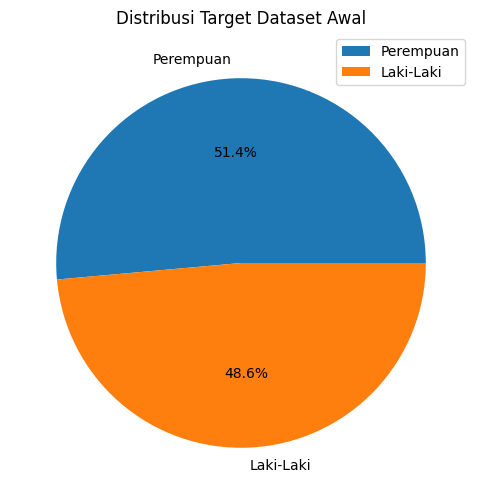

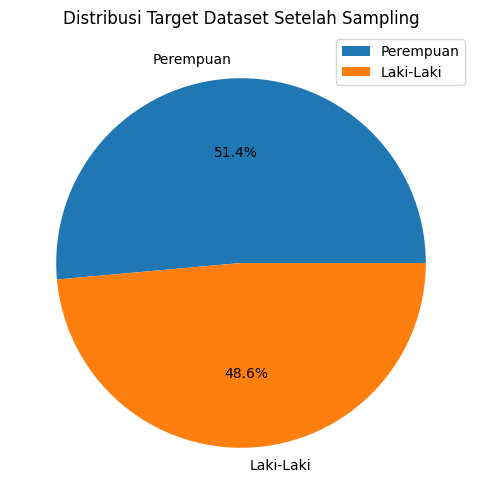

In [59]:
# Tamplikan penyebaran data dataset awal
plt.figure(figsize=(8, 6))
plt.pie(gender['jenis_kelamin'].value_counts(), labels=gender['jenis_kelamin'].value_counts().index, autopct='%1.1f%%')
plt.legend(['Perempuan', 'Laki-Laki'])
plt.title('Distribusi Target Dataset Awal')
plt.show()

# Tamplikan penyebaran data dataset awal
plt.figure(figsize=(8, 6))
plt.pie(gender['jenis_kelamin'].value_counts(), labels=gender['jenis_kelamin'].value_counts().index, autopct='%1.1f%%')
plt.legend(['Perempuan', 'Laki-Laki'])
plt.title('Distribusi Target Dataset Setelah Sampling')
plt.show()

In [60]:
gender['jenis_kelamin'] = gender['jenis_kelamin'].map({'Perempuan':1, 'Laki-Laki':0})

## **MODEL**

In [61]:
X = vector
y = gender['jenis_kelamin']

In [62]:
np.random.seed(42)

idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]

np.random.shuffle(idx_0)
np.random.shuffle(idx_1)

train_0 = int(len(idx_0) * 0.8)
train_1 = int(len(idx_1) * 0.8)

train_idx = np.concatenate([idx_0[:train_0], idx_1[:train_1]])
test_idx = np.concatenate([idx_0[train_0:], idx_1[train_1:]])

np.random.shuffle(train_idx)
np.random.shuffle(test_idx)

X_train = X[train_idx]
y_train = y.iloc[train_idx]
X_test = X[test_idx]
y_test = y.iloc[test_idx]

In [63]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(4879, 6917)
(4879,)
(1221, 6917)
(1221,)


In [64]:
gender['jenis_kelamin'].value_counts()

jenis_kelamin
1    3137
0    2963
Name: count, dtype: int64

In [65]:
np.random.seed(42)

data_major = gender[gender['jenis_kelamin'] == 1]
data_minor = gender[gender['jenis_kelamin'] == 0]

n_major = len(data_major)
n_minor = len(data_minor)

idx_minor = data_minor.index

idx_random = np.random.choice(idx_minor, size=n_major, replace=True)
data_minor_over = gender.loc[idx_random]
gender = pd.concat([data_major, data_minor_over])

In [66]:
gender['jenis_kelamin'].value_counts()

jenis_kelamin
1    3137
0    3137
Name: count, dtype: int64

In [67]:
def linear(X, w, b):
    z = np.dot(X,w) + b
    return z

In [68]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [69]:
def log_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

In [70]:
def gradient(X, y_true, y_pred):
    m = X.shape[0]
    error = y_pred - y_true

    dw = (1 / m) * np.dot(X.T, error)
    db = (1 / m) * np.sum(error)

    return dw, db

In [71]:
def update_parameter(w, b, dw, db, learning_rate):
    w_new = w - learning_rate * dw
    b_new = b - learning_rate * db

    return w_new, b_new

In [72]:
w = np.zeros(X_train.shape[1])
b = 0
learning_rate = 0.0001
ephocs = 1000
loss_history = []

for i in range(ephocs):
    z = linear(X_train, w,b)
    y_pred = sigmoid(z)

    loss_values = log_loss(y_train, y_pred)
    loss_history.append(loss_values)

    dw, db = gradient(X_train, y_train, y_pred)
    w, b = update_parameter(w, b, dw, db, learning_rate)

    if i % 50 == 0:
        print(f"Ephocs ke: {i} -- Loss Value: {loss_values}")
print(f"Loss Akhir: {loss_values}")

Ephocs ke: 0 -- Loss Value: 0.6931471805599453
Ephocs ke: 50 -- Loss Value: 0.6931435997836151
Ephocs ke: 100 -- Loss Value: 0.6931400216257828
Ephocs ke: 150 -- Loss Value: 0.6931364460800099
Ephocs ke: 200 -- Loss Value: 0.6931328731398743
Ephocs ke: 250 -- Loss Value: 0.6931293027989694
Ephocs ke: 300 -- Loss Value: 0.6931257350509054
Ephocs ke: 350 -- Loss Value: 0.6931221698893079
Ephocs ke: 400 -- Loss Value: 0.6931186073078189
Ephocs ke: 450 -- Loss Value: 0.6931150473000959
Ephocs ke: 500 -- Loss Value: 0.6931114898598125
Ephocs ke: 550 -- Loss Value: 0.6931079349806583
Ephocs ke: 600 -- Loss Value: 0.6931043826563383
Ephocs ke: 650 -- Loss Value: 0.6931008328805738
Ephocs ke: 700 -- Loss Value: 0.6930972856471013
Ephocs ke: 750 -- Loss Value: 0.6930937409496731
Ephocs ke: 800 -- Loss Value: 0.6930901987820574
Ephocs ke: 850 -- Loss Value: 0.693086659138038
Ephocs ke: 900 -- Loss Value: 0.6930831220114139
Ephocs ke: 950 -- Loss Value: 0.6930795873959998
Loss Akhir: 0.6930761259

In [73]:
def prediksi(X, w, b, threshold=0.5):
    z = linear(X, w, b)
    y_prob = sigmoid(z)
    y_class = [1 if p > threshold else 0 for p in y_prob]
    
    return np.array(y_class)

In [74]:
def evaluate(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return accuracy, precision, recall, f1

In [75]:
prediksi_train = prediksi(X_train, w, b)
akurasi_train = np.sum(prediksi_train == y_train) / len(X_train)
print("Train")
print(f"Akurasi Train: {akurasi_train:.4f}")

Train
Akurasi Train: 0.5142


In [76]:
prediksi_test = prediksi(X_test, w, b)
akurasi_test = np.sum(prediksi_test == y_test) / len(X_test)
print("Test")
print(f"Akurasi Test: {akurasi_test:.4f}")

Test
Akurasi Test: 0.5143


In [77]:
accuracy_train, recall_train, precision_train, f1_train = evaluate(y_train, prediksi_train)
accuracy_test, recall_test, precision_test, f1_test = evaluate(y_test, prediksi_test)

print("Train")
print(f"- Akurasi: {accuracy_train:.4f}\n- Recall: {recall_train:.4f}\n- Precision: {precision_train:.4f}\n- F1: {f1_train:.4f}")
print("\nTest")
print(f"- Akurasi: {accuracy_test:.4f}\n- Recall: {recall_test:.4f}\n- Precision: {precision_test:.4f}\n- F1: {f1_test:.4f}")


Train
- Akurasi: 0.5142
- Recall: 0.5142
- Precision: 1.0000
- F1: 0.6792

Test
- Akurasi: 0.5143
- Recall: 0.5143
- Precision: 1.0000
- F1: 0.6793


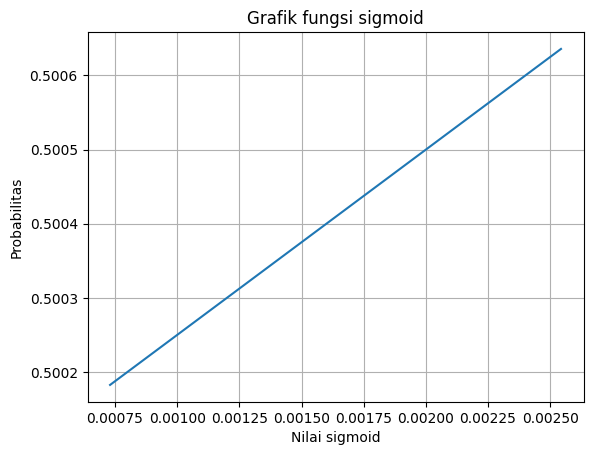

In [78]:
z_1 = np.dot(X_test, w) + b
z_sort = np.sort(z_1)
z_sorted = sigmoid(z_sort)

plt.plot(z_sort, z_sorted)
plt.grid(True)
plt.title('Grafik fungsi sigmoid')
plt.xlabel('Nilai sigmoid')
plt.ylabel('Probabilitas')
plt.show()

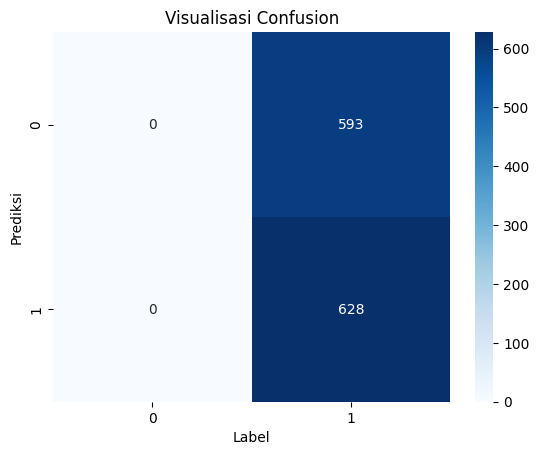

In [79]:
def confusion_matrix(y_true, y_pred):
    labels = np.unique(np.concatenate((y_true, y_pred)))
    label_idx = {label: i for i, label in enumerate(labels)}

    cm = np.zeros((len(labels), len(labels)), dtype=int)
    for yt, yp in zip(y_true, y_pred):
        i = label_idx[yt]
        j = label_idx[yp]
        cm[i, j] += 1
    return cm, labels

cm, labels = confusion_matrix(y_test, prediksi_test)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Label')
plt.ylabel('Prediksi')
plt.title('Visualisasi Confusion')
plt.show()